# AR Lab Generation — Formative Benchmark Summary

LLM-generated ARLEM lab specifications, benchmarked across providers, models, and prompt-specificity levels (L1–L4) on three lab topics.

Each topic was swept across **all registered models × L1–L4** (`--all-models --all-levels`), generating the full `Lab` JSON schema (`multi-module` structure). The first topic (VSEPR) was run **before** a round of schema/runtime fixes; the latter two were run **after**. This report keeps each topic separate and shows the effect of those fixes.

## Fixes applied between Run 1 (VSEPR) and Run 2 (Heart)

Run 1 surfaced three systematic failure modes. The fixes:

**1. Component discriminator — dual-field scheme** (`Code/Tools/json_lab.py`). Models emitted `{"type": "TextMeshProComponent"}` while the schema discriminated on `componentType: "textMeshPro"` — a field-name *and* value mismatch that caused thousands of `union_tag_not_found` errors. Components now carry two fields: an LLM-facing `type` (literal = class name, used as the discriminator, `exclude=True` so it is stripped on serialization) and a hidden `componentType` (`SkipJsonSchema`, the canonical Unity identifier the headset expects). The model reads/writes the naming it defaults to; the saved JSON keeps the headset contract.

**2. `ObjectChange.target` alias.** Models emitted `name` instead of the required `target`; `target` now accepts `name` as a validation alias.

**3. Anthropic completion truncation.** A hardcoded `max_tokens=8192` truncated every full L2–L4 lab (`IncompleteOutputException`). The Anthropic client is now built with an explicit timeout (disabling the SDK's non-streaming guard) and `max_tokens` raised to 32000 — no streaming rework, so token/cost tracking is unchanged.

**4. Removed deprecated `claude-3-haiku`** (returned 404 on every run).

The chart below shows success rate by provider, Run 1 vs Runs 2–3.

In [1]:
%matplotlib inline
import json
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 200)

# Compact per-run records embedded inline — notebook is self-contained.
RECORDS = json.loads(r'''[{"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gpt-5.5", "display_name": "GPT-5.5", "provider": "openai", "level": "L1", "success": true, "total_tokens": 1648, "completion_tokens": 918, "cost_usd": 0.03119, "wall_s": 21.8, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gpt-5.4-mini", "display_name": "GPT-5.4 Mini", "provider": "openai", "level": "L1", "success": true, "total_tokens": 1520, "completion_tokens": 790, "cost_usd": 0.0041025, "wall_s": 6.34, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gpt-5.4-nano", "display_name": "GPT-5.4 Nano", "provider": "openai", "level": "L1", "success": true, "total_tokens": 1941, "completion_tokens": 1211, "cost_usd": 0.00165975, "wall_s": 9.09, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gpt-5-mini", "display_name": "GPT-5 Mini", "provider": "openai", "level": "L1", "success": true, "total_tokens": 2718, "completion_tokens": 1988, "cost_usd": 0.0013023, "wall_s": 23.57, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gpt-5-nano", "display_name": "GPT-5 Nano", "provider": "openai", "level": "L1", "success": true, "total_tokens": 9645, "completion_tokens": 8915, "cost_usd": 0.0036025000000000002, "wall_s": 61.29, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gpt-4o-mini", "display_name": "GPT-4o Mini", "provider": "openai", "level": "L1", "success": true, "total_tokens": 1235, "completion_tokens": 579, "cost_usd": 0.0004458, "wall_s": 8.36, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "claude-opus-4-8", "display_name": "Claude Opus 4.8", "provider": "anthropic", "level": "L1", "success": true, "total_tokens": 4362, "completion_tokens": 2673, "cost_usd": 0.07526999999999999, "wall_s": 31.55, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "claude-sonnet-4-6", "display_name": "Claude Sonnet 4.6", "provider": "anthropic", "level": "L1", "success": true, "total_tokens": 4130, "completion_tokens": 2637, "cost_usd": 0.044034000000000004, "wall_s": 53.46, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "claude-haiku-4-5-20251001", "display_name": "Claude Haiku 4.5", "provider": "anthropic", "level": "L1", "success": true, "total_tokens": 3603, "completion_tokens": 2111, "cost_usd": 0.012047, "wall_s": 17.86, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "claude-3-haiku-20240307", "display_name": "Claude 3 Haiku (dep. Apr 2026)", "provider": "anthropic", "level": "L1", "success": false, "total_tokens": 0, "completion_tokens": 0, "cost_usd": 0.0, "wall_s": 0.68, "retries": 2, "num_objects": 0, "num_clips": 0, "fail_mode": "404 model-not-found"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gemini-3.1-pro-preview", "display_name": "Gemini 3.1 Pro", "provider": "google", "level": "L1", "success": true, "total_tokens": 2993, "completion_tokens": 1232, "cost_usd": 0.015798, "wall_s": 25.05, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gemini-3.1-flash-lite-preview", "display_name": "Gemini 3.1 Flash Lite", "provider": "google", "level": "L1", "success": true, "total_tokens": 1139, "completion_tokens": 632, "cost_usd": 0.00107475, "wall_s": 3.19, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gemini-3.5-flash", "display_name": "Gemini 3.5 Flash", "provider": "google", "level": "L1", "success": true, "total_tokens": 2961, "completion_tokens": 1475, "cost_usd": 0.014035500000000001, "wall_s": 15.71, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gemini-2.5-pro", "display_name": "Gemini 2.5 Pro", "provider": "google", "level": "L1", "success": true, "total_tokens": 3303, "completion_tokens": 1437, "cost_usd": 0.015003750000000001, "wall_s": 23.61, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gemini-2.5-flash", "display_name": "Gemini 2.5 Flash", "provider": "google", "level": "L1", "success": true, "total_tokens": 3589, "completion_tokens": 932, "cost_usd": 0.0024821, "wall_s": 15.26, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gemini-2.5-flash-lite", "display_name": "Gemini 2.5 Flash Lite", "provider": "google", "level": "L1", "success": true, "total_tokens": 1894, "completion_tokens": 1387, "cost_usd": 0.0006055, "wall_s": 5.02, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gpt-5.5", "display_name": "GPT-5.5", "provider": "openai", "level": "L2", "success": false, "total_tokens": 148688, "completion_tokens": 27674, "cost_usd": 1.43529, "wall_s": 334.08, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "404 model-not-found"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gpt-5.4-mini", "display_name": "GPT-5.4 Mini", "provider": "openai", "level": "L2", "success": false, "total_tokens": 60550, "completion_tokens": 12281, "cost_usd": 0.09146625, "wall_s": 62.69, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "404 model-not-found"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gpt-5.4-nano", "display_name": "GPT-5.4 Nano", "provider": "openai", "level": "L2", "success": false, "total_tokens": 114916, "completion_tokens": 18424, "cost_usd": 0.0423284, "wall_s": 140.06, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "404 model-not-found"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gpt-5-mini", "display_name": "GPT-5 Mini", "provider": "openai", "level": "L2", "success": false, "total_tokens": 138829, "completion_tokens": 26411, "cost_usd": 0.0327093, "wall_s": 301.74, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "404 model-not-found"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gpt-5-nano", "display_name": "GPT-5 Nano", "provider": "openai", "level": "L2", "success": false, "total_tokens": 69007, "completion_tokens": 40020, "cost_usd": 0.01745735, "wall_s": 309.81, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "404 model-not-found"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gpt-4o-mini", "display_name": "GPT-4o Mini", "provider": "openai", "level": "L2", "success": false, "total_tokens": 35779, "completion_tokens": 5175, "cost_usd": 0.0076955999999999995, "wall_s": 70.8, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "404 model-not-found"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "claude-opus-4-8", "display_name": "Claude Opus 4.8", "provider": "anthropic", "level": "L2", "success": false, "total_tokens": 94281, "completion_tokens": 42057, "cost_usd": 1.312545, "wall_s": 162.62, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "truncation (max_tokens)"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "claude-sonnet-4-6", "display_name": "Claude Sonnet 4.6", "provider": "anthropic", "level": "L2", "success": false, "total_tokens": 134532, "completion_tokens": 73728, "cost_usd": 1.288332, "wall_s": 294.48, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "truncation (max_tokens)"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "claude-haiku-4-5-20251001", "display_name": "Claude Haiku 4.5", "provider": "anthropic", "level": "L2", "success": true, "total_tokens": 13851, "completion_tokens": 7096, "cost_usd": 0.042234999999999995, "wall_s": 38.3, "retries": 0, "num_objects": 21, "num_clips": 12, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "claude-3-haiku-20240307", "display_name": "Claude 3 Haiku (dep. Apr 2026)", "provider": "anthropic", "level": "L2", "success": false, "total_tokens": 0, "completion_tokens": 0, "cost_usd": 0.0, "wall_s": 0.66, "retries": 2, "num_objects": 0, "num_clips": 0, "fail_mode": "404 model-not-found"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gemini-3.1-pro-preview", "display_name": "Gemini 3.1 Pro", "provider": "google", "level": "L2", "success": true, "total_tokens": 7232, "completion_tokens": 3766, "cost_usd": 0.04653, "wall_s": 48.02, "retries": 0, "num_objects": 13, "num_clips": 8, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gemini-3.1-flash-lite-preview", "display_name": "Gemini 3.1 Flash Lite", "provider": "google", "level": "L2", "success": true, "total_tokens": 1756, "completion_tokens": 1087, "cost_usd": 0.00179775, "wall_s": 4.2, "retries": 0, "num_objects": 4, "num_clips": 5, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gemini-3.5-flash", "display_name": "Gemini 3.5 Flash", "provider": "google", "level": "L2", "success": true, "total_tokens": 7240, "completion_tokens": 3353, "cost_usd": 0.0311805, "wall_s": 33.89, "retries": 0, "num_objects": 11, "num_clips": 8, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gemini-2.5-pro", "display_name": "Gemini 2.5 Pro", "provider": "google", "level": "L2", "success": true, "total_tokens": 8418, "completion_tokens": 4800, "cost_usd": 0.04883625, "wall_s": 58.26, "retries": 0, "num_objects": 15, "num_clips": 10, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gemini-2.5-flash", "display_name": "Gemini 2.5 Flash", "provider": "google", "level": "L2", "success": true, "total_tokens": 14347, "completion_tokens": 12058, "cost_usd": 0.030345700000000003, "wall_s": 59.57, "retries": 0, "num_objects": 31, "num_clips": 21, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gemini-2.5-flash-lite", "display_name": "Gemini 2.5 Flash Lite", "provider": "google", "level": "L2", "success": true, "total_tokens": 11680, "completion_tokens": 11011, "cost_usd": 0.0044713, "wall_s": 21.06, "retries": 0, "num_objects": 48, "num_clips": 24, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gpt-5.5", "display_name": "GPT-5.5", "provider": "openai", "level": "L3", "success": false, "total_tokens": 180086, "completion_tokens": 31728, "cost_usd": 1.69363, "wall_s": 393.66, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "404 model-not-found"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gpt-5.4-mini", "display_name": "GPT-5.4 Mini", "provider": "openai", "level": "L3", "success": false, "total_tokens": 76029, "completion_tokens": 11871, "cost_usd": 0.101538, "wall_s": 656.76, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "404 model-not-found"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gpt-5.4-nano", "display_name": "GPT-5.4 Nano", "provider": "openai", "level": "L3", "success": false, "total_tokens": 115181, "completion_tokens": 17691, "cost_usd": 0.04161175, "wall_s": 128.14, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "404 model-not-found"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gpt-5-mini", "display_name": "GPT-5 Mini", "provider": "openai", "level": "L3", "success": false, "total_tokens": 129343, "completion_tokens": 27017, "cost_usd": 0.0315591, "wall_s": 290.57, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "404 model-not-found"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gpt-5-nano", "display_name": "GPT-5 Nano", "provider": "openai", "level": "L3", "success": false, "total_tokens": 72429, "completion_tokens": 54182, "cost_usd": 0.022585150000000002, "wall_s": 405.08, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "404 model-not-found"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gpt-4o-mini", "display_name": "GPT-4o Mini", "provider": "openai", "level": "L3", "success": false, "total_tokens": 20120, "completion_tokens": 3013, "cost_usd": 0.00437385, "wall_s": 44.7, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "404 model-not-found"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "claude-opus-4-8", "display_name": "Claude Opus 4.8", "provider": "anthropic", "level": "L3", "success": true, "total_tokens": 17017, "completion_tokens": 8058, "cost_usd": 0.246245, "wall_s": 72.06, "retries": 0, "num_objects": 25, "num_clips": 15, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "claude-sonnet-4-6", "display_name": "Claude Sonnet 4.6", "provider": "anthropic", "level": "L3", "success": false, "total_tokens": 135981, "completion_tokens": 73728, "cost_usd": 1.2926790000000001, "wall_s": 293.1, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "truncation (max_tokens)"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "claude-haiku-4-5-20251001", "display_name": "Claude Haiku 4.5", "provider": "anthropic", "level": "L3", "success": true, "total_tokens": 37665, "completion_tokens": 11459, "cost_usd": 0.08350099999999999, "wall_s": 70.35, "retries": 2, "num_objects": 32, "num_clips": 8, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "claude-3-haiku-20240307", "display_name": "Claude 3 Haiku (dep. Apr 2026)", "provider": "anthropic", "level": "L3", "success": false, "total_tokens": 0, "completion_tokens": 0, "cost_usd": 0.0, "wall_s": 0.56, "retries": 2, "num_objects": 0, "num_clips": 0, "fail_mode": "404 model-not-found"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gemini-3.1-pro-preview", "display_name": "Gemini 3.1 Pro", "provider": "google", "level": "L3", "success": true, "total_tokens": 6682, "completion_tokens": 3164, "cost_usd": 0.039598, "wall_s": 47.21, "retries": 0, "num_objects": 11, "num_clips": 8, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gemini-3.1-flash-lite-preview", "display_name": "Gemini 3.1 Flash Lite", "provider": "google", "level": "L3", "success": true, "total_tokens": 1860, "completion_tokens": 1045, "cost_usd": 0.00177125, "wall_s": 4.13, "retries": 0, "num_objects": 4, "num_clips": 5, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gemini-3.5-flash", "display_name": "Gemini 3.5 Flash", "provider": "google", "level": "L3", "success": true, "total_tokens": 6324, "completion_tokens": 3416, "cost_usd": 0.0319665, "wall_s": 26.12, "retries": 0, "num_objects": 8, "num_clips": 5, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gemini-2.5-pro", "display_name": "Gemini 2.5 Pro", "provider": "google", "level": "L3", "success": true, "total_tokens": 10525, "completion_tokens": 7477, "cost_usd": 0.07578875, "wall_s": 60.74, "retries": 0, "num_objects": 26, "num_clips": 10, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gemini-2.5-flash", "display_name": "Gemini 2.5 Flash", "provider": "google", "level": "L3", "success": true, "total_tokens": 9211, "completion_tokens": 7005, "cost_usd": 0.017757000000000002, "wall_s": 35.55, "retries": 0, "num_objects": 21, "num_clips": 14, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gemini-2.5-flash-lite", "display_name": "Gemini 2.5 Flash Lite", "provider": "google", "level": "L3", "success": true, "total_tokens": 15296, "completion_tokens": 14481, "cost_usd": 0.0058739000000000005, "wall_s": 32.35, "retries": 0, "num_objects": 47, "num_clips": 14, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gpt-5.5", "display_name": "GPT-5.5", "provider": "openai", "level": "L4", "success": false, "total_tokens": 255461, "completion_tokens": 45225, "cost_usd": 2.40793, "wall_s": 571.11, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "404 model-not-found"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gpt-5.4-mini", "display_name": "GPT-5.4 Mini", "provider": "openai", "level": "L4", "success": false, "total_tokens": 71854, "completion_tokens": 11785, "cost_usd": 0.09808425000000001, "wall_s": 56.16, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "404 model-not-found"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gpt-5.4-nano", "display_name": "GPT-5.4 Nano", "provider": "openai", "level": "L4", "success": true, "total_tokens": 186334, "completion_tokens": 22550, "cost_usd": 0.06094430000000001, "wall_s": 166.52, "retries": 4, "num_objects": 30, "num_clips": 11, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gpt-5-mini", "display_name": "GPT-5 Mini", "provider": "openai", "level": "L4", "success": false, "total_tokens": 186868, "completion_tokens": 31697, "cost_usd": 0.042293849999999994, "wall_s": 363.07, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "404 model-not-found"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gpt-5-nano", "display_name": "GPT-5 Nano", "provider": "openai", "level": "L4", "success": false, "total_tokens": 58151, "completion_tokens": 38267, "cost_usd": 0.016301, "wall_s": 267.37, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "404 model-not-found"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gpt-4o-mini", "display_name": "GPT-4o Mini", "provider": "openai", "level": "L4", "success": false, "total_tokens": 27656, "completion_tokens": 3958, "cost_usd": 0.005929499999999999, "wall_s": 50.43, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "404 model-not-found"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "claude-opus-4-8", "display_name": "Claude Opus 4.8", "provider": "anthropic", "level": "L4", "success": false, "total_tokens": 173781, "completion_tokens": 73728, "cost_usd": 2.343465, "wall_s": 221.98, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "truncation (max_tokens)"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "claude-sonnet-4-6", "display_name": "Claude Sonnet 4.6", "provider": "anthropic", "level": "L4", "success": false, "total_tokens": 149022, "completion_tokens": 73728, "cost_usd": 1.331802, "wall_s": 299.04, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "truncation (max_tokens)"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "claude-haiku-4-5-20251001", "display_name": "Claude Haiku 4.5", "provider": "anthropic", "level": "L4", "success": false, "total_tokens": 149013, "completion_tokens": 73728, "cost_usd": 0.443925, "wall_s": 141.7, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "truncation (max_tokens)"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "claude-3-haiku-20240307", "display_name": "Claude 3 Haiku (dep. Apr 2026)", "provider": "anthropic", "level": "L4", "success": false, "total_tokens": 0, "completion_tokens": 0, "cost_usd": 0.0, "wall_s": 0.49, "retries": 2, "num_objects": 0, "num_clips": 0, "fail_mode": "404 model-not-found"}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gemini-3.1-pro-preview", "display_name": "Gemini 3.1 Pro", "provider": "google", "level": "L4", "success": true, "total_tokens": 11570, "completion_tokens": 4011, "cost_usd": 0.052502, "wall_s": 77.64, "retries": 0, "num_objects": 26, "num_clips": 15, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gemini-3.1-flash-lite-preview", "display_name": "Gemini 3.1 Flash Lite", "provider": "google", "level": "L4", "success": true, "total_tokens": 3453, "completion_tokens": 1268, "cost_usd": 0.00244825, "wall_s": 6.49, "retries": 0, "num_objects": 5, "num_clips": 5, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gemini-3.5-flash", "display_name": "Gemini 3.5 Flash", "provider": "google", "level": "L4", "success": true, "total_tokens": 14618, "completion_tokens": 9498, "cost_usd": 0.0887595, "wall_s": 60.08, "retries": 0, "num_objects": 24, "num_clips": 13, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gemini-2.5-pro", "display_name": "Gemini 2.5 Pro", "provider": "google", "level": "L4", "success": true, "total_tokens": 9715, "completion_tokens": 5342, "cost_usd": 0.05615125, "wall_s": 55.71, "retries": 0, "num_objects": 24, "num_clips": 10, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gemini-2.5-flash", "display_name": "Gemini 2.5 Flash", "provider": "google", "level": "L4", "success": true, "total_tokens": 42510, "completion_tokens": 18706, "cost_usd": 0.047420500000000004, "wall_s": 161.27, "retries": 0, "num_objects": 72, "num_clips": 37, "fail_mode": ""}, {"topic": "vsepr_molecular_geometry", "phase": "Run 1 \u2014 pre-fix baseline", "model": "gemini-2.5-flash-lite", "display_name": "Gemini 2.5 Flash Lite", "provider": "google", "level": "L4", "success": true, "total_tokens": 14908, "completion_tokens": 12723, "cost_usd": 0.0053077, "wall_s": 28.98, "retries": 0, "num_objects": 47, "num_clips": 20, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gpt-5.5", "display_name": "GPT-5.5", "provider": "openai", "level": "L1", "success": true, "total_tokens": 1785, "completion_tokens": 1047, "cost_usd": 0.0351, "wall_s": 19.6, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gpt-5.4-mini", "display_name": "GPT-5.4 Mini", "provider": "openai", "level": "L1", "success": true, "total_tokens": 1632, "completion_tokens": 894, "cost_usd": 0.0045765, "wall_s": 6.72, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gpt-5.4-nano", "display_name": "GPT-5.4 Nano", "provider": "openai", "level": "L1", "success": true, "total_tokens": 1881, "completion_tokens": 1143, "cost_usd": 0.0015763499999999998, "wall_s": 7.28, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gpt-5-mini", "display_name": "GPT-5 Mini", "provider": "openai", "level": "L1", "success": true, "total_tokens": 3581, "completion_tokens": 2843, "cost_usd": 0.0018165, "wall_s": 26.05, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gpt-5-nano", "display_name": "GPT-5 Nano", "provider": "openai", "level": "L1", "success": true, "total_tokens": 4208, "completion_tokens": 3470, "cost_usd": 0.0014249, "wall_s": 23.6, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gpt-4o-mini", "display_name": "GPT-4o Mini", "provider": "openai", "level": "L1", "success": true, "total_tokens": 1335, "completion_tokens": 671, "cost_usd": 0.0005022, "wall_s": 8.89, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "claude-opus-4-8", "display_name": "Claude Opus 4.8", "provider": "anthropic", "level": "L1", "success": true, "total_tokens": 3693, "completion_tokens": 2024, "cost_usd": 0.058945, "wall_s": 24.46, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "claude-sonnet-4-6", "display_name": "Claude Sonnet 4.6", "provider": "anthropic", "level": "L1", "success": true, "total_tokens": 4322, "completion_tokens": 2816, "cost_usd": 0.046758, "wall_s": 53.95, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "claude-haiku-4-5-20251001", "display_name": "Claude Haiku 4.5", "provider": "anthropic", "level": "L1", "success": true, "total_tokens": 3569, "completion_tokens": 2064, "cost_usd": 0.011824999999999999, "wall_s": 16.14, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gemini-3.1-pro-preview", "display_name": "Gemini 3.1 Pro", "provider": "google", "level": "L1", "success": true, "total_tokens": 3743, "completion_tokens": 899, "cost_usd": 0.011770000000000001, "wall_s": 27.18, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gemini-3.1-flash-lite-preview", "display_name": "Gemini 3.1 Flash Lite", "provider": "google", "level": "L1", "success": true, "total_tokens": 1417, "completion_tokens": 926, "cost_usd": 0.00151175, "wall_s": 3.91, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gemini-3.5-flash", "display_name": "Gemini 3.5 Flash", "provider": "google", "level": "L1", "success": true, "total_tokens": 3137, "completion_tokens": 1357, "cost_usd": 0.0129495, "wall_s": 14.86, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gemini-2.5-pro", "display_name": "Gemini 2.5 Pro", "provider": "google", "level": "L1", "success": true, "total_tokens": 2912, "completion_tokens": 1245, "cost_usd": 0.013063749999999999, "wall_s": 18.86, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gemini-2.5-flash", "display_name": "Gemini 2.5 Flash", "provider": "google", "level": "L1", "success": true, "total_tokens": 3085, "completion_tokens": 1201, "cost_usd": 0.0031498, "wall_s": 12.48, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gemini-2.5-flash-lite", "display_name": "Gemini 2.5 Flash Lite", "provider": "google", "level": "L1", "success": true, "total_tokens": 1706, "completion_tokens": 1215, "cost_usd": 0.0005350999999999999, "wall_s": 4.08, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gpt-5.5", "display_name": "GPT-5.5", "provider": "openai", "level": "L2", "success": true, "total_tokens": 43167, "completion_tokens": 16908, "cost_usd": 0.6385350000000001, "wall_s": 150.35, "retries": 2, "num_objects": 34, "num_clips": 18, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gpt-5.4-mini", "display_name": "GPT-5.4 Mini", "provider": "openai", "level": "L2", "success": true, "total_tokens": 19948, "completion_tokens": 6644, "cost_usd": 0.039876, "wall_s": 33.54, "retries": 2, "num_objects": 19, "num_clips": 9, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gpt-5.4-nano", "display_name": "GPT-5.4 Nano", "provider": "openai", "level": "L2", "success": true, "total_tokens": 76954, "completion_tokens": 15480, "cost_usd": 0.0316448, "wall_s": 98.44, "retries": 4, "num_objects": 27, "num_clips": 17, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gpt-5-mini", "display_name": "GPT-5 Mini", "provider": "openai", "level": "L2", "success": false, "total_tokens": 77247, "completion_tokens": 19295, "cost_usd": 0.020269799999999998, "wall_s": 202.82, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "404 model-not-found"}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gpt-5-nano", "display_name": "GPT-5 Nano", "provider": "openai", "level": "L2", "success": true, "total_tokens": 33044, "completion_tokens": 20386, "cost_usd": 0.008787300000000001, "wall_s": 737.23, "retries": 2, "num_objects": 20, "num_clips": 7, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gpt-4o-mini", "display_name": "GPT-4o Mini", "provider": "openai", "level": "L2", "success": true, "total_tokens": 9421, "completion_tokens": 2499, "cost_usd": 0.0025377, "wall_s": 30.81, "retries": 2, "num_objects": 10, "num_clips": 4, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "claude-opus-4-8", "display_name": "Claude Opus 4.8", "provider": "anthropic", "level": "L2", "success": true, "total_tokens": 45200, "completion_tokens": 13520, "cost_usd": 0.49640000000000006, "wall_s": 118.92, "retries": 2, "num_objects": 12, "num_clips": 16, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "claude-sonnet-4-6", "display_name": "Claude Sonnet 4.6", "provider": "anthropic", "level": "L2", "success": true, "total_tokens": 17252, "completion_tokens": 10485, "cost_usd": 0.177576, "wall_s": 131.76, "retries": 0, "num_objects": 40, "num_clips": 10, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "claude-haiku-4-5-20251001", "display_name": "Claude Haiku 4.5", "provider": "anthropic", "level": "L2", "success": true, "total_tokens": 32136, "completion_tokens": 9304, "cost_usd": 0.069352, "wall_s": 61.67, "retries": 2, "num_objects": 17, "num_clips": 9, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gemini-3.1-pro-preview", "display_name": "Gemini 3.1 Pro", "provider": "google", "level": "L2", "success": true, "total_tokens": 5445, "completion_tokens": 2333, "cost_usd": 0.029302, "wall_s": 35.21, "retries": 0, "num_objects": 7, "num_clips": 6, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gemini-3.1-flash-lite-preview", "display_name": "Gemini 3.1 Flash Lite", "provider": "google", "level": "L2", "success": true, "total_tokens": 1860, "completion_tokens": 1207, "cost_usd": 0.0019737500000000002, "wall_s": 4.29, "retries": 0, "num_objects": 4, "num_clips": 5, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gemini-3.5-flash", "display_name": "Gemini 3.5 Flash", "provider": "google", "level": "L2", "success": true, "total_tokens": 4710, "completion_tokens": 2404, "cost_usd": 0.0226155, "wall_s": 19.95, "retries": 0, "num_objects": 7, "num_clips": 6, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gemini-2.5-pro", "display_name": "Gemini 2.5 Pro", "provider": "google", "level": "L2", "success": true, "total_tokens": 7807, "completion_tokens": 2708, "cost_usd": 0.02789625, "wall_s": 47.31, "retries": 0, "num_objects": 6, "num_clips": 8, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gemini-2.5-flash", "display_name": "Gemini 2.5 Flash", "provider": "google", "level": "L2", "success": true, "total_tokens": 15744, "completion_tokens": 8110, "cost_usd": 0.0204709, "wall_s": 61.1, "retries": 0, "num_objects": 18, "num_clips": 14, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gemini-2.5-flash-lite", "display_name": "Gemini 2.5 Flash Lite", "provider": "google", "level": "L2", "success": true, "total_tokens": 7347, "completion_tokens": 6694, "cost_usd": 0.0027429000000000004, "wall_s": 17.45, "retries": 0, "num_objects": 34, "num_clips": 14, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gpt-5.5", "display_name": "GPT-5.5", "provider": "openai", "level": "L3", "success": true, "total_tokens": 46515, "completion_tokens": 19242, "cost_usd": 0.713625, "wall_s": 180.58, "retries": 2, "num_objects": 34, "num_clips": 22, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gpt-5.4-mini", "display_name": "GPT-5.4 Mini", "provider": "openai", "level": "L3", "success": true, "total_tokens": 23285, "completion_tokens": 7366, "cost_usd": 0.04508625, "wall_s": 35.4, "retries": 2, "num_objects": 25, "num_clips": 9, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gpt-5.4-nano", "display_name": "GPT-5.4 Nano", "provider": "openai", "level": "L3", "success": true, "total_tokens": 38972, "completion_tokens": 11469, "cost_usd": 0.01983685, "wall_s": 72.44, "retries": 2, "num_objects": 28, "num_clips": 13, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gpt-5-mini", "display_name": "GPT-5 Mini", "provider": "openai", "level": "L3", "success": false, "total_tokens": 63512, "completion_tokens": 15384, "cost_usd": 0.016449599999999998, "wall_s": 186.28, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "404 model-not-found"}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gpt-5-nano", "display_name": "GPT-5 Nano", "provider": "openai", "level": "L3", "success": true, "total_tokens": 32679, "completion_tokens": 21401, "cost_usd": 0.009124299999999998, "wall_s": 138.8, "retries": 2, "num_objects": 23, "num_clips": 7, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gpt-4o-mini", "display_name": "GPT-4o Mini", "provider": "openai", "level": "L3", "success": true, "total_tokens": 11024, "completion_tokens": 3185, "cost_usd": 0.00308685, "wall_s": 42.17, "retries": 2, "num_objects": 11, "num_clips": 6, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "claude-opus-4-8", "display_name": "Claude Opus 4.8", "provider": "anthropic", "level": "L3", "success": true, "total_tokens": 14506, "completion_tokens": 5492, "cost_usd": 0.18237, "wall_s": 52.38, "retries": 0, "num_objects": 10, "num_clips": 11, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "claude-sonnet-4-6", "display_name": "Claude Sonnet 4.6", "provider": "anthropic", "level": "L3", "success": true, "total_tokens": 17070, "completion_tokens": 10122, "cost_usd": 0.172674, "wall_s": 130.18, "retries": 0, "num_objects": 27, "num_clips": 16, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "claude-haiku-4-5-20251001", "display_name": "Claude Haiku 4.5", "provider": "anthropic", "level": "L3", "success": true, "total_tokens": 78414, "completion_tokens": 17201, "cost_usd": 0.147218, "wall_s": 105.72, "retries": 4, "num_objects": 16, "num_clips": 14, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gemini-3.1-pro-preview", "display_name": "Gemini 3.1 Pro", "provider": "google", "level": "L3", "success": true, "total_tokens": 6570, "completion_tokens": 3192, "cost_usd": 0.039934, "wall_s": 38.75, "retries": 0, "num_objects": 8, "num_clips": 7, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gemini-3.1-flash-lite-preview", "display_name": "Gemini 3.1 Flash Lite", "provider": "google", "level": "L3", "success": true, "total_tokens": 6976, "completion_tokens": 2364, "cost_usd": 0.004699, "wall_s": 8.03, "retries": 2, "num_objects": 5, "num_clips": 5, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gemini-3.5-flash", "display_name": "Gemini 3.5 Flash", "provider": "google", "level": "L3", "success": true, "total_tokens": 5831, "completion_tokens": 3371, "cost_usd": 0.0315615, "wall_s": 23.77, "retries": 0, "num_objects": 9, "num_clips": 8, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gemini-2.5-pro", "display_name": "Gemini 2.5 Pro", "provider": "google", "level": "L3", "success": true, "total_tokens": 5011, "completion_tokens": 2716, "cost_usd": 0.02817875, "wall_s": 27.55, "retries": 0, "num_objects": 9, "num_clips": 8, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gemini-2.5-flash", "display_name": "Gemini 2.5 Flash", "provider": "google", "level": "L3", "success": true, "total_tokens": 20961, "completion_tokens": 8699, "cost_usd": 0.021992, "wall_s": 81.85, "retries": 0, "num_objects": 19, "num_clips": 18, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gemini-2.5-flash-lite", "display_name": "Gemini 2.5 Flash Lite", "provider": "google", "level": "L3", "success": true, "total_tokens": 7824, "completion_tokens": 7009, "cost_usd": 0.0028851000000000003, "wall_s": 18.7, "retries": 0, "num_objects": 28, "num_clips": 12, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gpt-5.5", "display_name": "GPT-5.5", "provider": "openai", "level": "L4", "success": true, "total_tokens": 165184, "completion_tokens": 37990, "cost_usd": 1.7756699999999999, "wall_s": 404.92, "retries": 4, "num_objects": 57, "num_clips": 34, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gpt-5.4-mini", "display_name": "GPT-5.4 Mini", "provider": "openai", "level": "L4", "success": true, "total_tokens": 29910, "completion_tokens": 10896, "cost_usd": 0.0632925, "wall_s": 49.75, "retries": 2, "num_objects": 29, "num_clips": 17, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gpt-5.4-nano", "display_name": "GPT-5.4 Nano", "provider": "openai", "level": "L4", "success": true, "total_tokens": 176330, "completion_tokens": 33800, "cost_usd": 0.070756, "wall_s": 224.09, "retries": 4, "num_objects": 47, "num_clips": 35, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gpt-5-mini", "display_name": "GPT-5 Mini", "provider": "openai", "level": "L4", "success": true, "total_tokens": 64751, "completion_tokens": 26346, "cost_usd": 0.02156835, "wall_s": 277.53, "retries": 2, "num_objects": 50, "num_clips": 32, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gpt-5-nano", "display_name": "GPT-5 Nano", "provider": "openai", "level": "L4", "success": true, "total_tokens": 28563, "completion_tokens": 17513, "cost_usd": 0.0075577000000000005, "wall_s": 109.01, "retries": 2, "num_objects": 3, "num_clips": 4, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gpt-4o-mini", "display_name": "GPT-4o Mini", "provider": "openai", "level": "L4", "success": true, "total_tokens": 5868, "completion_tokens": 2192, "cost_usd": 0.0018666, "wall_s": 33.36, "retries": 0, "num_objects": 1, "num_clips": 1, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "claude-opus-4-8", "display_name": "Claude Opus 4.8", "provider": "anthropic", "level": "L4", "success": true, "total_tokens": 28221, "completion_tokens": 16768, "cost_usd": 0.476465, "wall_s": 147.51, "retries": 0, "num_objects": 40, "num_clips": 35, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "claude-sonnet-4-6", "display_name": "Claude Sonnet 4.6", "provider": "anthropic", "level": "L4", "success": true, "total_tokens": 114408, "completion_tokens": 88293, "cost_usd": 1.40274, "wall_s": 708.4, "retries": 2, "num_objects": 73, "num_clips": 40, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "claude-haiku-4-5-20251001", "display_name": "Claude Haiku 4.5", "provider": "anthropic", "level": "L4", "success": true, "total_tokens": 83971, "completion_tokens": 33969, "cost_usd": 0.219847, "wall_s": 207.95, "retries": 2, "num_objects": 36, "num_clips": 41, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gemini-3.1-pro-preview", "display_name": "Gemini 3.1 Pro", "provider": "google", "level": "L4", "success": true, "total_tokens": 15750, "completion_tokens": 7930, "cost_usd": 0.099926, "wall_s": 93.93, "retries": 0, "num_objects": 28, "num_clips": 35, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gemini-3.1-flash-lite-preview", "display_name": "Gemini 3.1 Flash Lite", "provider": "google", "level": "L4", "success": true, "total_tokens": 3455, "completion_tokens": 1072, "cost_usd": 0.00220375, "wall_s": 4.56, "retries": 0, "num_objects": 4, "num_clips": 5, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gemini-3.5-flash", "display_name": "Gemini 3.5 Flash", "provider": "google", "level": "L4", "success": true, "total_tokens": 10963, "completion_tokens": 6767, "cost_usd": 0.0644775, "wall_s": 41.16, "retries": 0, "num_objects": 19, "num_clips": 16, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gemini-2.5-pro", "display_name": "Gemini 2.5 Pro", "provider": "google", "level": "L4", "success": true, "total_tokens": 12139, "completion_tokens": 4520, "cost_usd": 0.04817875, "wall_s": 63.36, "retries": 0, "num_objects": 12, "num_clips": 20, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gemini-2.5-flash", "display_name": "Gemini 2.5 Flash", "provider": "google", "level": "L4", "success": true, "total_tokens": 27499, "completion_tokens": 20023, "cost_usd": 0.050772399999999995, "wall_s": 100.46, "retries": 0, "num_objects": 53, "num_clips": 91, "fail_mode": ""}, {"topic": "heart_anatomy_and_blood_flow", "phase": "Run 2 \u2014 post-fix", "model": "gemini-2.5-flash-lite", "display_name": "Gemini 2.5 Flash Lite", "provider": "google", "level": "L4", "success": true, "total_tokens": 13906, "completion_tokens": 11523, "cost_usd": 0.0048475, "wall_s": 27.08, "retries": 0, "num_objects": 34, "num_clips": 35, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gpt-5.5", "display_name": "GPT-5.5", "provider": "openai", "level": "L1", "success": true, "total_tokens": 1857, "completion_tokens": 1083, "cost_usd": 0.036359999999999996, "wall_s": 29.54, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gpt-5.4-mini", "display_name": "GPT-5.4 Mini", "provider": "openai", "level": "L1", "success": true, "total_tokens": 1584, "completion_tokens": 810, "cost_usd": 0.0042255, "wall_s": 7.15, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gpt-5.4-nano", "display_name": "GPT-5.4 Nano", "provider": "openai", "level": "L1", "success": true, "total_tokens": 1718, "completion_tokens": 944, "cost_usd": 0.0013348000000000001, "wall_s": 6.71, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gpt-5-mini", "display_name": "GPT-5 Mini", "provider": "openai", "level": "L1", "success": true, "total_tokens": 2383, "completion_tokens": 1609, "cost_usd": 0.0010815, "wall_s": 17.56, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gpt-5-nano", "display_name": "GPT-5 Nano", "provider": "openai", "level": "L1", "success": true, "total_tokens": 4724, "completion_tokens": 3950, "cost_usd": 0.0016187, "wall_s": 19.85, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gpt-4o-mini", "display_name": "GPT-4o Mini", "provider": "openai", "level": "L1", "success": true, "total_tokens": 1278, "completion_tokens": 578, "cost_usd": 0.00045180000000000003, "wall_s": 7.61, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "claude-opus-4-8", "display_name": "Claude Opus 4.8", "provider": "anthropic", "level": "L1", "success": true, "total_tokens": 3741, "completion_tokens": 2007, "cost_usd": 0.058844999999999995, "wall_s": 27.35, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "claude-sonnet-4-6", "display_name": "Claude Sonnet 4.6", "provider": "anthropic", "level": "L1", "success": true, "total_tokens": 4127, "completion_tokens": 2606, "cost_usd": 0.043653, "wall_s": 56.6, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "claude-haiku-4-5-20251001", "display_name": "Claude Haiku 4.5", "provider": "anthropic", "level": "L1", "success": true, "total_tokens": 3332, "completion_tokens": 1812, "cost_usd": 0.01058, "wall_s": 20.07, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gemini-3.1-pro-preview", "display_name": "Gemini 3.1 Pro", "provider": "google", "level": "L1", "success": true, "total_tokens": 4766, "completion_tokens": 774, "cost_usd": 0.010378, "wall_s": 34.08, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gemini-3.1-flash-lite-preview", "display_name": "Gemini 3.1 Flash Lite", "provider": "google", "level": "L1", "success": true, "total_tokens": 1250, "completion_tokens": 705, "cost_usd": 0.0011937500000000001, "wall_s": 3.26, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gemini-3.5-flash", "display_name": "Gemini 3.5 Flash", "provider": "google", "level": "L1", "success": true, "total_tokens": 3239, "completion_tokens": 1540, "cost_usd": 0.014677500000000001, "wall_s": 16.99, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gemini-2.5-pro", "display_name": "Gemini 2.5 Pro", "provider": "google", "level": "L1", "success": true, "total_tokens": 3139, "completion_tokens": 1235, "cost_usd": 0.01303125, "wall_s": 21.07, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gemini-2.5-flash", "display_name": "Gemini 2.5 Flash", "provider": "google", "level": "L1", "success": true, "total_tokens": 4248, "completion_tokens": 1300, "cost_usd": 0.0034135, "wall_s": 18.51, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gemini-2.5-flash-lite", "display_name": "Gemini 2.5 Flash Lite", "provider": "google", "level": "L1", "success": true, "total_tokens": 1615, "completion_tokens": 1070, "cost_usd": 0.0004825, "wall_s": 4.11, "retries": 0, "num_objects": 0, "num_clips": 0, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gpt-5.5", "display_name": "GPT-5.5", "provider": "openai", "level": "L2", "success": true, "total_tokens": 57608, "completion_tokens": 18623, "cost_usd": 0.753615, "wall_s": 235.65, "retries": 2, "num_objects": 35, "num_clips": 17, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gpt-5.4-mini", "display_name": "GPT-5.4 Mini", "provider": "openai", "level": "L2", "success": true, "total_tokens": 17133, "completion_tokens": 4610, "cost_usd": 0.030137249999999997, "wall_s": 24.12, "retries": 2, "num_objects": 15, "num_clips": 5, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gpt-5.4-nano", "display_name": "GPT-5.4 Nano", "provider": "openai", "level": "L2", "success": true, "total_tokens": 28142, "completion_tokens": 9378, "cost_usd": 0.0154753, "wall_s": 66.79, "retries": 2, "num_objects": 17, "num_clips": 13, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gpt-5-mini", "display_name": "GPT-5 Mini", "provider": "openai", "level": "L2", "success": false, "total_tokens": 79576, "completion_tokens": 18335, "cost_usd": 0.02018715, "wall_s": 198.36, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "schema validation"}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gpt-5-nano", "display_name": "GPT-5 Nano", "provider": "openai", "level": "L2", "success": false, "total_tokens": 46699, "completion_tokens": 25425, "cost_usd": 0.011233700000000001, "wall_s": 131.53, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "schema validation"}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gpt-4o-mini", "display_name": "GPT-4o Mini", "provider": "openai", "level": "L2", "success": true, "total_tokens": 2511, "completion_tokens": 555, "cost_usd": 0.0006264, "wall_s": 10.45, "retries": 0, "num_objects": 3, "num_clips": 3, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "claude-opus-4-8", "display_name": "Claude Opus 4.8", "provider": "anthropic", "level": "L2", "success": true, "total_tokens": 101908, "completion_tokens": 21608, "cost_usd": 0.9417, "wall_s": 190.62, "retries": 4, "num_objects": 21, "num_clips": 14, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "claude-sonnet-4-6", "display_name": "Claude Sonnet 4.6", "provider": "anthropic", "level": "L2", "success": true, "total_tokens": 14028, "completion_tokens": 7246, "cost_usd": 0.12903599999999998, "wall_s": 102.82, "retries": 0, "num_objects": 24, "num_clips": 9, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "claude-haiku-4-5-20251001", "display_name": "Claude Haiku 4.5", "provider": "anthropic", "level": "L2", "success": true, "total_tokens": 33151, "completion_tokens": 9349, "cost_usd": 0.070547, "wall_s": 69.65, "retries": 2, "num_objects": 13, "num_clips": 15, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gemini-3.1-pro-preview", "display_name": "Gemini 3.1 Pro", "provider": "google", "level": "L2", "success": true, "total_tokens": 6897, "completion_tokens": 3543, "cost_usd": 0.04393, "wall_s": 47.27, "retries": 0, "num_objects": 13, "num_clips": 7, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gemini-3.1-flash-lite-preview", "display_name": "Gemini 3.1 Flash Lite", "provider": "google", "level": "L2", "success": true, "total_tokens": 1973, "completion_tokens": 1266, "cost_usd": 0.00207575, "wall_s": 4.44, "retries": 0, "num_objects": 5, "num_clips": 5, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gemini-3.5-flash", "display_name": "Gemini 3.5 Flash", "provider": "google", "level": "L2", "success": true, "total_tokens": 6731, "completion_tokens": 3512, "cost_usd": 0.032668499999999996, "wall_s": 28.84, "retries": 0, "num_objects": 15, "num_clips": 7, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gemini-2.5-pro", "display_name": "Gemini 2.5 Pro", "provider": "google", "level": "L2", "success": true, "total_tokens": 7472, "completion_tokens": 3158, "cost_usd": 0.03246375, "wall_s": 47.25, "retries": 0, "num_objects": 10, "num_clips": 7, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gemini-2.5-flash", "display_name": "Gemini 2.5 Flash", "provider": "google", "level": "L2", "success": true, "total_tokens": 8061, "completion_tokens": 5629, "cost_usd": 0.0142846, "wall_s": 31.95, "retries": 0, "num_objects": 24, "num_clips": 11, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gemini-2.5-flash-lite", "display_name": "Gemini 2.5 Flash Lite", "provider": "google", "level": "L2", "success": true, "total_tokens": 4877, "completion_tokens": 4170, "cost_usd": 0.0017387, "wall_s": 12.59, "retries": 0, "num_objects": 21, "num_clips": 15, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gpt-5.5", "display_name": "GPT-5.5", "provider": "openai", "level": "L3", "success": true, "total_tokens": 88648, "completion_tokens": 21616, "cost_usd": 0.98364, "wall_s": 198.2, "retries": 4, "num_objects": 44, "num_clips": 19, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gpt-5.4-mini", "display_name": "GPT-5.4 Mini", "provider": "openai", "level": "L3", "success": true, "total_tokens": 23353, "completion_tokens": 8123, "cost_usd": 0.047976000000000005, "wall_s": 37.42, "retries": 2, "num_objects": 24, "num_clips": 12, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gpt-5.4-nano", "display_name": "GPT-5.4 Nano", "provider": "openai", "level": "L3", "success": true, "total_tokens": 93199, "completion_tokens": 15865, "cost_usd": 0.035298050000000004, "wall_s": 109.1, "retries": 4, "num_objects": 25, "num_clips": 16, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gpt-5-mini", "display_name": "GPT-5 Mini", "provider": "openai", "level": "L3", "success": true, "total_tokens": 59667, "completion_tokens": 13702, "cost_usd": 0.01511595, "wall_s": 149.54, "retries": 4, "num_objects": 16, "num_clips": 7, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gpt-5-nano", "display_name": "GPT-5 Nano", "provider": "openai", "level": "L3", "success": true, "total_tokens": 57653, "completion_tokens": 26847, "cost_usd": 0.012279100000000001, "wall_s": 151.53, "retries": 4, "num_objects": 15, "num_clips": 6, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gpt-4o-mini", "display_name": "GPT-4o Mini", "provider": "openai", "level": "L3", "success": true, "total_tokens": 2788, "completion_tokens": 675, "cost_usd": 0.00072195, "wall_s": 14.74, "retries": 0, "num_objects": 2, "num_clips": 4, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "claude-opus-4-8", "display_name": "Claude Opus 4.8", "provider": "anthropic", "level": "L3", "success": true, "total_tokens": 44626, "completion_tokens": 12988, "cost_usd": 0.48289, "wall_s": 118.19, "retries": 2, "num_objects": 17, "num_clips": 11, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "claude-sonnet-4-6", "display_name": "Claude Sonnet 4.6", "provider": "anthropic", "level": "L3", "success": true, "total_tokens": 17069, "completion_tokens": 10120, "cost_usd": 0.172647, "wall_s": 138.49, "retries": 0, "num_objects": 32, "num_clips": 13, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "claude-haiku-4-5-20251001", "display_name": "Claude Haiku 4.5", "provider": "anthropic", "level": "L3", "success": true, "total_tokens": 38696, "completion_tokens": 12383, "cost_usd": 0.088228, "wall_s": 85.08, "retries": 2, "num_objects": 15, "num_clips": 17, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gemini-3.1-pro-preview", "display_name": "Gemini 3.1 Pro", "provider": "google", "level": "L3", "success": true, "total_tokens": 7830, "completion_tokens": 3354, "cost_usd": 0.041968, "wall_s": 53.6, "retries": 0, "num_objects": 10, "num_clips": 7, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gemini-3.1-flash-lite-preview", "display_name": "Gemini 3.1 Flash Lite", "provider": "google", "level": "L3", "success": true, "total_tokens": 2080, "completion_tokens": 1220, "cost_usd": 0.002045, "wall_s": 4.52, "retries": 0, "num_objects": 5, "num_clips": 5, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gemini-3.5-flash", "display_name": "Gemini 3.5 Flash", "provider": "google", "level": "L3", "success": true, "total_tokens": 6088, "completion_tokens": 2819, "cost_usd": 0.026661, "wall_s": 25.05, "retries": 0, "num_objects": 8, "num_clips": 6, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gemini-2.5-pro", "display_name": "Gemini 2.5 Pro", "provider": "google", "level": "L3", "success": true, "total_tokens": 7284, "completion_tokens": 3112, "cost_usd": 0.032195, "wall_s": 44.82, "retries": 0, "num_objects": 10, "num_clips": 7, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gemini-2.5-flash", "display_name": "Gemini 2.5 Flash", "provider": "google", "level": "L3", "success": true, "total_tokens": 13290, "completion_tokens": 6204, "cost_usd": 0.015768, "wall_s": 52.01, "retries": 0, "num_objects": 18, "num_clips": 18, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gemini-2.5-flash-lite", "display_name": "Gemini 2.5 Flash Lite", "provider": "google", "level": "L3", "success": true, "total_tokens": 4562, "completion_tokens": 3702, "cost_usd": 0.0015668000000000001, "wall_s": 9.1, "retries": 0, "num_objects": 17, "num_clips": 12, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gpt-5.5", "display_name": "GPT-5.5", "provider": "openai", "level": "L4", "success": true, "total_tokens": 233372, "completion_tokens": 41311, "cost_usd": 2.199635, "wall_s": 399.52, "retries": 4, "num_objects": 67, "num_clips": 36, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gpt-5.4-mini", "display_name": "GPT-5.4 Mini", "provider": "openai", "level": "L4", "success": true, "total_tokens": 42885, "completion_tokens": 13933, "cost_usd": 0.0844125, "wall_s": 59.81, "retries": 2, "num_objects": 43, "num_clips": 22, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gpt-5.4-nano", "display_name": "GPT-5.4 Nano", "provider": "openai", "level": "L4", "success": true, "total_tokens": 90591, "completion_tokens": 22698, "cost_usd": 0.0419511, "wall_s": 161.78, "retries": 4, "num_objects": 27, "num_clips": 13, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gpt-5-mini", "display_name": "GPT-5 Mini", "provider": "openai", "level": "L4", "success": false, "total_tokens": 114364, "completion_tokens": 26213, "cost_usd": 0.02895045, "wall_s": 292.19, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "404 model-not-found"}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gpt-5-nano", "display_name": "GPT-5 Nano", "provider": "openai", "level": "L4", "success": false, "total_tokens": 111706, "completion_tokens": 50726, "cost_usd": 0.0233394, "wall_s": 1556.61, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "schema validation"}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gpt-4o-mini", "display_name": "GPT-4o Mini", "provider": "openai", "level": "L4", "success": false, "total_tokens": 42039, "completion_tokens": 8959, "cost_usd": 0.0103374, "wall_s": 122.77, "retries": 5, "num_objects": 0, "num_clips": 0, "fail_mode": "schema validation"}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "claude-opus-4-8", "display_name": "Claude Opus 4.8", "provider": "anthropic", "level": "L4", "success": true, "total_tokens": 27279, "completion_tokens": 16395, "cost_usd": 0.464295, "wall_s": 153.13, "retries": 0, "num_objects": 55, "num_clips": 33, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "claude-sonnet-4-6", "display_name": "Claude Sonnet 4.6", "provider": "anthropic", "level": "L4", "success": true, "total_tokens": 28034, "completion_tokens": 19843, "cost_usd": 0.322218, "wall_s": 264.06, "retries": 0, "num_objects": 74, "num_clips": 28, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "claude-haiku-4-5-20251001", "display_name": "Claude Haiku 4.5", "provider": "anthropic", "level": "L4", "success": true, "total_tokens": 133375, "completion_tokens": 31374, "cost_usd": 0.258871, "wall_s": 221.13, "retries": 4, "num_objects": 51, "num_clips": 23, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gemini-3.1-pro-preview", "display_name": "Gemini 3.1 Pro", "provider": "google", "level": "L4", "success": true, "total_tokens": 11421, "completion_tokens": 6311, "cost_usd": 0.079798, "wall_s": 71.31, "retries": 0, "num_objects": 26, "num_clips": 21, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gemini-3.1-flash-lite-preview", "display_name": "Gemini 3.1 Flash Lite", "provider": "google", "level": "L4", "success": true, "total_tokens": 3115, "completion_tokens": 1082, "cost_usd": 0.0021312500000000003, "wall_s": 4.12, "retries": 0, "num_objects": 4, "num_clips": 5, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gemini-3.5-flash", "display_name": "Gemini 3.5 Flash", "provider": "google", "level": "L4", "success": true, "total_tokens": 13118, "completion_tokens": 7321, "cost_usd": 0.0689385, "wall_s": 53.76, "retries": 0, "num_objects": 30, "num_clips": 12, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gemini-2.5-pro", "display_name": "Gemini 2.5 Pro", "provider": "google", "level": "L4", "success": true, "total_tokens": 13057, "completion_tokens": 6097, "cost_usd": 0.06351125, "wall_s": 73.17, "retries": 0, "num_objects": 32, "num_clips": 16, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gemini-2.5-flash", "display_name": "Gemini 2.5 Flash", "provider": "google", "level": "L4", "success": true, "total_tokens": 38827, "completion_tokens": 16793, "cost_usd": 0.0425924, "wall_s": 145.54, "retries": 0, "num_objects": 64, "num_clips": 40, "fail_mode": ""}, {"topic": "apparent_retrograde_motion", "phase": "Run 3 \u2014 post-fix", "model": "gemini-2.5-flash-lite", "display_name": "Gemini 2.5 Flash Lite", "provider": "google", "level": "L4", "success": true, "total_tokens": 11694, "completion_tokens": 9661, "cost_usd": 0.0040677000000000005, "wall_s": 25.78, "retries": 0, "num_objects": 50, "num_clips": 26, "fail_mode": ""}]''')
df = pd.DataFrame(RECORDS)

LEVELS = ['L1', 'L2', 'L3', 'L4']
PROVIDERS = ['openai', 'anthropic', 'google']

def success_by_provider_level(sub):
    rows = []
    for p in PROVIDERS:
        d = sub[sub.provider == p]
        row = {'provider': p}
        for lv in LEVELS:
            dl = d[d.level == lv]
            row[lv] = f"{int(dl.success.sum())}/{len(dl)}" if len(dl) else '-'
        row['total'] = f"{int(d.success.sum())}/{len(d)}"
        rows.append(row)
    return pd.DataFrame(rows).set_index('provider')

def model_grid(sub):
    rows = []
    for m in sub.display_name.unique():
        d = sub[sub.display_name == m]
        row = {'model': m}
        for lv in LEVELS:
            dl = d[d.level == lv]
            row[lv] = ('OK' if bool(dl.success.iloc[0]) else 'X') if len(dl) else '-'
        row['ok'] = f"{int(d.success.sum())}/{len(d)}"
        fm = [x for x in d[~d.success].fail_mode.tolist() if x]
        row['fail mode'] = max(set(fm), key=fm.count) if fm else ''
        rows.append(row)
    return pd.DataFrame(rows).set_index('model')

def topic_stats(sub):
    ok = int(sub.success.sum()); n = len(sub)
    succ = sub[sub.success & (sub.level != 'L1')]
    return {
        'success': f"{ok}/{n} ({ok/n:.0%})",
        'wall_min': round(float(sub.wall_s.sum())/60, 1),
        'cost_usd': round(float(sub.cost_usd.sum()), 2),
        'avg_objects_L2-4': round(float(succ.num_objects.mean()), 1) if len(succ) else 0,
        'avg_clips_L2-4': round(float(succ.num_clips.mean()), 1) if len(succ) else 0,
    }


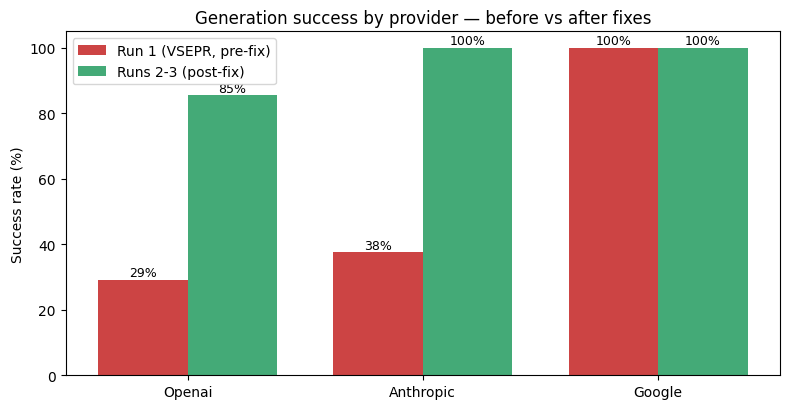

In [2]:
before = df[df.phase.str.startswith('Run 1')]
after = df[~df.phase.str.startswith('Run 1')]
rate = lambda d, p: (d[d.provider == p].success.mean() * 100) if len(d[d.provider == p]) else 0
import numpy as np
x = np.arange(len(PROVIDERS)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.2))
b1 = ax.bar(x - w/2, [rate(before, p) for p in PROVIDERS], w, label='Run 1 (VSEPR, pre-fix)', color='#c44')
b2 = ax.bar(x + w/2, [rate(after, p) for p in PROVIDERS], w, label='Runs 2-3 (post-fix)', color='#4a7')
ax.set_xticks(x); ax.set_xticklabels([p.capitalize() for p in PROVIDERS])
ax.set_ylabel('Success rate (%)'); ax.set_ylim(0, 105)
ax.set_title('Generation success by provider — before vs after fixes')
ax.legend()
for b in list(b1) + list(b2):
    ax.annotate(f'{b.get_height():.0f}%', (b.get_x()+b.get_width()/2, b.get_height()+1), ha='center', fontsize=9)
plt.tight_layout(); plt.show()

## VSEPR Molecular Geometry

*Run 1 — pre-fix baseline*

In [3]:
sub = df[df.topic == 'vsepr_molecular_geometry']
print('Topic stats:', topic_stats(sub))
print()
print('Success by provider x level:')
display(success_by_provider_level(sub))
print('Per-model grid:')
display(model_grid(sub))
fm = sub[~sub.success].fail_mode
if len(fm):
    print('Failure modes:')
    display(fm.value_counts().rename_axis('mode').to_frame('failed runs'))
else:
    print('No failures.')

Topic stats: {'success': '37/64 (58%)', 'wall_min': 122.5, 'cost_usd': 15.35, 'avg_objects_L2-4': 24.8, 'avg_clips_L2-4': 12.6}

Success by provider x level:


,L1,L2,L3,L4,total
provider,,,,,
openai,6/6,0/6,0/6,1/6,7/24
anthropic,3/4,1/4,2/4,0/4,6/16
google,6/6,6/6,6/6,6/6,24/24


Per-model grid:


,L1,L2,L3,L4,ok,fail mode
model,,,,,,
GPT-5.5,OK,X,X,X,1/4,404 model-not-found
GPT-5.4 Mini,OK,X,X,X,1/4,404 model-not-found
GPT-5.4 Nano,OK,X,X,OK,2/4,404 model-not-found
GPT-5 Mini,OK,X,X,X,1/4,404 model-not-found
GPT-5 Nano,OK,X,X,X,1/4,404 model-not-found
GPT-4o Mini,OK,X,X,X,1/4,404 model-not-found
Claude Opus 4.8,OK,X,OK,X,2/4,truncation (max_tokens)
Claude Sonnet 4.6,OK,X,X,X,1/4,truncation (max_tokens)
Claude Haiku 4.5,OK,OK,OK,X,3/4,truncation (max_tokens)


Failure modes:


,failed runs
mode,
404 model-not-found,21
truncation (max_tokens),6


## Heart Anatomy & Blood Flow

*Run 2 — post-fix*

In [4]:
sub = df[df.topic == 'heart_anatomy_and_blood_flow']
print('Topic stats:', topic_stats(sub))
print()
print('Success by provider x level:')
display(success_by_provider_level(sub))
print('Per-model grid:')
display(model_grid(sub))
fm = sub[~sub.success].fail_mode
if len(fm):
    print('Failure modes:')
    display(fm.value_counts().rename_axis('mode').to_frame('failed runs'))
else:
    print('No failures.')

Topic stats: {'success': '58/60 (97%)', 'wall_min': 94.2, 'cost_usd': 7.54, 'avg_objects_L2-4': 23.1, 'avg_clips_L2-4': 17.2}

Success by provider x level:


,L1,L2,L3,L4,total
provider,,,,,
openai,6/6,5/6,5/6,6/6,22/24
anthropic,3/3,3/3,3/3,3/3,12/12
google,6/6,6/6,6/6,6/6,24/24


Per-model grid:


,L1,L2,L3,L4,ok,fail mode
model,,,,,,
GPT-5.5,OK,OK,OK,OK,4/4,
GPT-5.4 Mini,OK,OK,OK,OK,4/4,
GPT-5.4 Nano,OK,OK,OK,OK,4/4,
GPT-5 Mini,OK,X,X,OK,2/4,404 model-not-found
GPT-5 Nano,OK,OK,OK,OK,4/4,
GPT-4o Mini,OK,OK,OK,OK,4/4,
Claude Opus 4.8,OK,OK,OK,OK,4/4,
Claude Sonnet 4.6,OK,OK,OK,OK,4/4,
Claude Haiku 4.5,OK,OK,OK,OK,4/4,


Failure modes:


,failed runs
mode,
404 model-not-found,2


## Apparent Retrograde Motion

*Run 3 — post-fix*

In [5]:
sub = df[df.topic == 'apparent_retrograde_motion']
print('Topic stats:', topic_stats(sub))
print()
print('Success by provider x level:')
display(success_by_provider_level(sub))
print('Per-model grid:')
display(model_grid(sub))
fm = sub[~sub.success].fail_mode
if len(fm):
    print('Failure modes:')
    display(fm.value_counts().rename_axis('mode').to_frame('failed runs'))
else:
    print('No failures.')

Topic stats: {'success': '55/60 (92%)', 'wall_min': 104.8, 'cost_usd': 7.96, 'avg_objects_L2-4': 24.9, 'avg_clips_L2-4': 14.1}

Success by provider x level:


,L1,L2,L3,L4,total
provider,,,,,
openai,6/6,4/6,6/6,3/6,19/24
anthropic,3/3,3/3,3/3,3/3,12/12
google,6/6,6/6,6/6,6/6,24/24


Per-model grid:


,L1,L2,L3,L4,ok,fail mode
model,,,,,,
GPT-5.5,OK,OK,OK,OK,4/4,
GPT-5.4 Mini,OK,OK,OK,OK,4/4,
GPT-5.4 Nano,OK,OK,OK,OK,4/4,
GPT-5 Mini,OK,X,OK,X,2/4,schema validation
GPT-5 Nano,OK,X,OK,X,2/4,schema validation
GPT-4o Mini,OK,OK,OK,X,3/4,schema validation
Claude Opus 4.8,OK,OK,OK,OK,4/4,
Claude Sonnet 4.6,OK,OK,OK,OK,4/4,
Claude Haiku 4.5,OK,OK,OK,OK,4/4,


Failure modes:


,failed runs
mode,
schema validation,4
404 model-not-found,1


## Takeaways

- The discriminator dual-field scheme moved OpenAI from a near-total L2–L4 failure to near-complete success without changing the saved JSON's headset contract.
- The Anthropic timeout/`max_tokens` fix eliminated the truncation failures; full L4 labs now generate.
- Gemini was already union-free and unaffected (perfect throughout).
- Residual failures concentrate in the weakest small model (gpt-5-mini), which hallucinates field names / component types — a model-capability floor, not a schema issue.